In [1]:
#Q1. Creating Non-Linear Dataset

# Import libraries
import pandas as pd
from sklearn.datasets import make_moons

# Generate moon dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print(df.head(10))

# Display shape
print("Shape of dataset:", df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959
Shape of dataset: (500, 2)


In [2]:
#Q2. Scaling the Data

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale the data
X_scaled = scaler.fit_transform(df)

# First 5 rows
print(X_scaled[:5])

[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


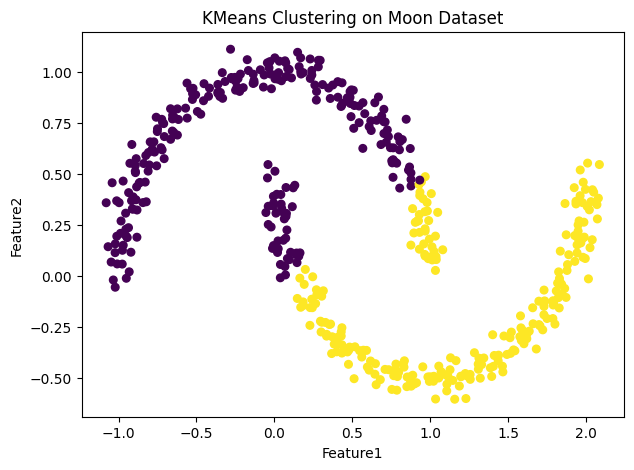

In [3]:
#Q3. KMeans Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create model
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Predict clusters
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels
df["kmeans_cluster"] = kmeans_labels

# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["kmeans_cluster"],
    cmap="viridis",
    s=30
)

plt.title("KMeans Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

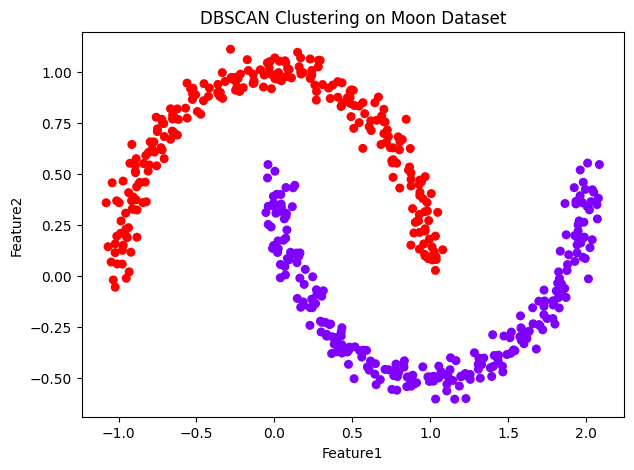

In [4]:
#Q4. DBSCAN Clustering

from sklearn.cluster import DBSCAN

# Create model
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

# Predict clusters
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add labels
df["dbscan_cluster"] = dbscan_labels

# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["dbscan_cluster"],
    cmap="rainbow",
    s=30
)

plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

## Q5. Comparing KMeans vs DBSCAN

### KMeans
- Assumes clusters are circular.
- Does not separate the moon-shaped clusters correctly.
- Assigns every point to a cluster.

### DBSCAN
- Groups points based on density.
- Correctly identifies the moon-shaped clusters.
- Detects noise points (label = -1).

### Conclusion
DBSCAN performs better than KMeans for the moon dataset because it can handle non-linear cluster shapes.

In [5]:
#Q6. Tuning DBSCAN Parameters

results = []

eps_values = [0.2, 0.3, 0.4, 0.5]

for eps in eps_values:

    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(X_scaled)

    # Count clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count noise
    noise = list(labels).count(-1)

    results.append([eps, n_clusters, noise])

# Create table
result_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "No_of_Clusters",
        "Noise_Points"
    ]
)

print(result_df)

   eps  No_of_Clusters  Noise_Points
0  0.2               2             0
1  0.3               2             0
2  0.4               2             0
3  0.5               2             0


Taken Predefined Dataset from Sklearn

In [ ]:
#Q7. DBSCAN on Wine Dataset

from sklearn.datasets import load_wine
import pandas as pd

# Load Wine dataset
wine = load_wine(as_frame=True)

# Create DataFrame
df_wine = wine.frame

# Select numerical features
X = df_wine.drop("target", axis=1)

print(X.head())
print("Shape:", X.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [ ]:
#Q8. Scaling Wine Dataset

from sklearn.preprocessing import StandardScaler

# Select numerical features
X = df_wine.drop("target", axis=1)

# Scale Wine dataset
scaler = StandardScaler()
X_scaled_wine = scaler.fit_transform(X)

In [ ]:
#Question 9. DBSCAN on Scaled Wine Dataset

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)

clusters = dbscan.fit_predict(X_scaled_wine)

df_wine["DBSCAN_Cluster"] = clusters

print(df_wine["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
-1    85
 0    66
 4     9
 1     8
 2     5
 3     5
Name: count, dtype: int64


In [ ]:
#Q10. PCA Visualization of Wine Dataset using DBSCAN

from sklearn.decomposition import PCA
import pandas as pd

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_wine)

# Create DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Add DBSCAN cluster labels
pca_df["Cluster"] = clusters

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.36198848 0.1920749 ]


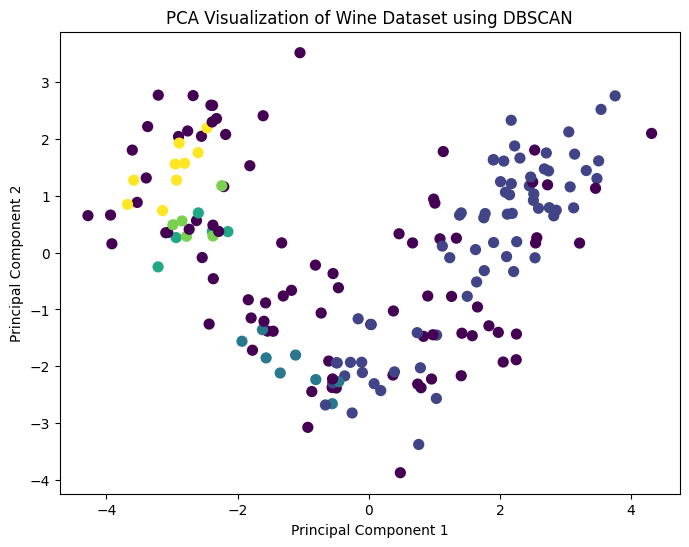

In [ ]:
# Visualizing PCA Results

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=50
)

plt.title("PCA Visualization of Wine Dataset using DBSCAN")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Observation

- The first principal component (PC1) explains **36.20%** of the total variance.
- The second principal component (PC2) explains **19.21%** of the total variance.
- Together, the two principal components retain approximately **55.41%** of the original information.
- PCA successfully reduced the 13-dimensional Wine dataset to 2 dimensions while preserving a significant amount of information.

In [17]:
print("Total Variance Retained:", pca.explained_variance_ratio_.sum())

Total Variance Retained: 0.5540633835693527
